In [3]:
from torch.utils.data import DataLoader
import transformers
from datasets import Dataset
from accelerate import Accelerator
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import evaluate
import torch
import numpy as np

In [4]:
df = pd.read_csv(r"C:\Users\stasm\SpamClassificator\source.csv")

In [5]:
df["Category"].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

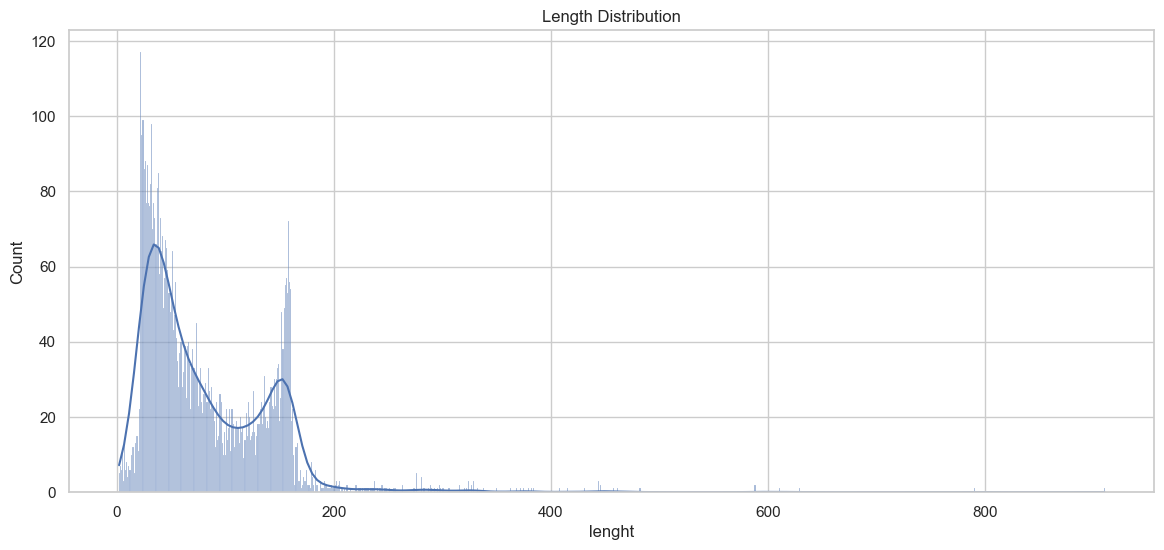

In [6]:
df["lenght"] = df["Message"].str.len()
plt.figure(figsize=(14,6))
sns.set_theme(style = 'whitegrid')
sns.histplot(data = df, x = "lenght", discrete = True, kde = True)

plt.title("Length Distribution")
plt.show()

In [7]:
tokenizer = transformers.AutoTokenizer.from_pretrained("google-bert/bert-base-cased")

In [8]:
def tokenize_function(examples):
    return tokenizer(
        examples["Message"], 
        padding="max_length", 
        truncation=True, 
        max_length=200
    )

In [9]:
df['label'] = df['Category'].map({'ham' : 0, 'spam' : 1})
hf_dataset = Dataset.from_pandas(df)

In [10]:
tokenized_dataset = hf_dataset.map(tokenize_function, batched=True)
tokenized_dataset.set_format(type = "torch", columns = ['input_ids', 'attention_mask', 'label'])

Map: 100%|██████████| 5572/5572 [00:00<00:00, 6861.62 examples/s]


In [11]:
splits = tokenized_dataset.train_test_split(test_size = 0.3, seed = 42)
train_dataset = splits['train']
test_dataset = splits['test']

In [12]:
accelerator = Accelerator()

In [13]:
model = transformers.AutoModelForSequenceClassification.from_pretrained(
    "google-bert/bert-base-cased",
    num_labels = 2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
trained_args = transformers.TrainingArguments(
    output_dir = "model_args",
    eval_strategy = 'epoch',
    per_device_train_batch_size = 16,
	per_device_eval_batch_size = 16,
	num_train_epochs = 5,
	report_to='none'
)

In [15]:
metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, label = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=label)

In [18]:
trainer = transformers.Trainer(
    model = model,
    args = trained_args,
    train_dataset = train_dataset,
	eval_dataset = test_dataset,
	compute_metrics = compute_metrics
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,No log,0.049257,0.939815
2,No log,0.073418,0.960739
3,0.060900,0.073158,0.958140
4,0.060900,0.065565,0.970115
5,0.004500,0.067459,0.970115


TrainOutput(global_step=1220, training_loss=0.026795644719214712, metrics={'train_runtime': 1591.4203, 'train_samples_per_second': 12.253, 'train_steps_per_second': 0.767, 'total_flos': 2004166242000000.0, 'train_loss': 0.026795644719214712, 'epoch': 5.0})

In [20]:
trainer.save_model("./final_class_model")
tokenizer.save_pretrained("./final_class_model")

('./final_class_model\\tokenizer_config.json',
 './final_class_model\\special_tokens_map.json',
 './final_class_model\\vocab.txt',
 './final_class_model\\added_tokens.json',
 './final_class_model\\tokenizer.json')